<a href="https://colab.research.google.com/github/amandachipolito/Trabalho-BCI/blob/alternativo/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1 - Instalar Bibliotecas

In [32]:
!python3 -m pip install --upgrade pip
!pip download numpy pathlib scipy gdown matplotlib scikit-learn MNE
!pip install numpy pathlib scipy gdown matplotlib scikit-learn MNE


  File was already downloaded /content/numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
  File was already downloaded /content/pathlib-1.0.1-py3-none-any.whl
  File was already downloaded /content/scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
  File was already downloaded /content/gdown-6.0.0-py3-none-any.whl
  File was already downloaded /content/matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl
  File was already downloaded /content/scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl
  File was already downloaded /content/mne-1.12.1-py3-none-any.whl
  File was already downloaded /content/beautifulsoup4-4.14.3-py3-none-any.whl
  File was already downloaded /content/filelock-3.29.0-py3-none-any.whl
  File was already downloaded /content/requests-2.33.1-py3-none-any.whl
  File was already downloaded /content/tqdm-4.67.3-py3-none-any.whl
  File was already downloaded /content/contourpy

In [33]:
import sys
!{sys.executable} -m ensurepip --default-pip

/usr/bin/python3: No module named ensurepip


# 2 - Importar Bibliotecas

In [34]:
import glob
import os
import sys
import numpy as np
from pathlib import Path
from scipy.io import loadmat


# 3 - Definir pasta local e link do Google Drive

In [35]:
IN_COLAB = "google.colab" in sys.modules

DATA_DIR = Path("/content/Projeto_BCI" if IN_COLAB else "./Projeto_BCI").resolve()

GDRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1l2wfRKe3_xGU0otL7aIvcwXn578fGs7a?usp=sharing"

print("Pasta dos dados:", DATA_DIR)

Pasta dos dados: /content/Projeto_BCI


# 4 - Baixar arquivos .mat

In [36]:
if not DATA_DIR.exists():
    import gdown

    print(f"Baixando arquivos para: {DATA_DIR}")
    gdown.download_folder(
        GDRIVE_FOLDER_URL,
        output=str(DATA_DIR),
        quiet=False,
        use_cookies=False
    )
else:
    print("A pasta já existe. Download não realizado novamente.")

Baixando arquivos para: /content/Projeto_BCI


Retrieving folder contents


Processing file 1hcGwlkAvLsWXAgBysJ9ViiWTBF8rehJy covertShiftsOfAttention_VPgao.mat
Processing file 197oMPVpbWBI7VXXkdU7BJRDgqbE_wA8R covertShiftsOfAttention_VPiaa.mat
Processing file 12_dSoB8hhZtq0cSridCDb-7h2zm-GusP covertShiftsOfAttention_VPiac.mat
Processing file 1U6XgesX7VVqmeAbSsg01k9lpR74xVutY covertShiftsOfAttention_VPiae.mat
Processing file 1SN8k7KaGsU7ymM9tMemJywyODtckP0qt covertShiftsOfAttention_VPiah.mat
Processing file 1LUtYUjSmLK-wu5dcTt1bOcfQ2kZ2SVNp covertShiftsOfAttention_VPiai.mat
Processing file 1tHEGa4o-M90s5t1t5n_hdkOsAC50Jj1c covertShiftsOfAttention_VPmk.mat
Processing file 1g4PWIV9VgIVMvS9JRFR0Cn52bNvLtFpK covertShiftsOfAttention_VPnh.mat


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1hcGwlkAvLsWXAgBysJ9ViiWTBF8rehJy
From (redirected): https://drive.google.com/uc?id=1hcGwlkAvLsWXAgBysJ9ViiWTBF8rehJy&confirm=t&uuid=f559f4a8-efa7-4ac6-996b-bcd38c110cf3
To: /content/Projeto_BCI/covertShiftsOfAttention_VPgao.mat
100%|██████████| 150M/150M [00:03<00:00, 39.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=197oMPVpbWBI7VXXkdU7BJRDgqbE_wA8R
From (redirected): https://drive.google.com/uc?id=197oMPVpbWBI7VXXkdU7BJRDgqbE_wA8R&confirm=t&uuid=5b9aa479-66c8-4976-923f-b610fc6046d0
To: /content/Projeto_BCI/covertShiftsOfAttention_VPiaa.mat
100%|██████████| 228M/228M [00:01<00:00, 124MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=12_dSoB8hhZtq0cSridCDb-7h2zm-GusP
From (redirected): https://drive.google.com/uc?id=12_dSoB8hhZtq0cSridCDb-7h2zm-GusP&confirm=t&uuid=991e7f8d-e855

# 5 - Listar arquivos encontrados

In [37]:
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.mat")))

print(f"{len(files)} arquivos .mat encontrados:")

for file in files:
    print(os.path.basename(file))

8 arquivos .mat encontrados:
covertShiftsOfAttention_VPgao.mat
covertShiftsOfAttention_VPiaa.mat
covertShiftsOfAttention_VPiac.mat
covertShiftsOfAttention_VPiae.mat
covertShiftsOfAttention_VPiah.mat
covertShiftsOfAttention_VPiai.mat
covertShiftsOfAttention_VPmk.mat
covertShiftsOfAttention_VPnh.mat


# 6 - Carregar os dados corretamente

In [38]:
data_list = []
fs_list = []
nomes_arquivos = []

for fname in files:
    nome = os.path.basename(fname)

    mat = loadmat(fname, squeeze_me=True, struct_as_record=False)

    data = mat["data"]

    X = np.asarray(data.X, dtype=float)
    fs = int(data.fs)

    data_list.append(X)
    fs_list.append(fs)
    nomes_arquivos.append(nome)

    print(f"{nome}")
    print(f"  X shape: {X.shape}")
    print(f"  fs: {fs} Hz")
    print()

covertShiftsOfAttention_VPgao.mat
  X shape: (579736, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiaa.mat
  X shape: (581804, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiac.mat
  X shape: (657660, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiae.mat
  X shape: (613408, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiah.mat
  X shape: (604788, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPiai.mat
  X shape: (429348, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPmk.mat
  X shape: (592640, 62)
  fs: 200 Hz

covertShiftsOfAttention_VPnh.mat
  X shape: (596576, 62)
  fs: 200 Hz



# 7 - Conferir se todos tem a mesma frequência de amostragem

In [39]:
frequencias = sorted(set(fs_list))

print("Frequências encontradas:", frequencias)

if len(frequencias) == 1:
    fs = frequencias[0]
    print(f"Todos os arquivos têm fs = {fs} Hz")
else:
    print("Atenção: existem frequências diferentes entre os arquivos.")

Frequências encontradas: [200]
Todos os arquivos têm fs = 200 Hz


# 8 - Conferir o formato dos dados

In [40]:
X_exemplo = data_list[0]

print("Shape do primeiro arquivo:", X_exemplo.shape)

n_amostras = X_exemplo.shape[0]
n_canais = X_exemplo.shape[1]

print("Número de amostras:", n_amostras)
print("Número de canais:", n_canais)

Shape do primeiro arquivo: (579736, 62)
Número de amostras: 579736
Número de canais: 62


# 9 - Criar a função de filtragem

In [41]:
from scipy.signal import butter, filtfilt, iirnotch, sosfiltfilt

def aplicar_filtros_eeg(X, fs):
    X = np.asarray(X, dtype=float)

    b_notch, a_notch = iirnotch(60.0, 30.0, fs)
    X_notch = filtfilt(b_notch, a_notch, X, axis=0)

    sos = butter(
        4,
        [8, 14],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    X_filtrado = sosfiltfilt(sos, X_notch, axis=0)

    return X_filtrado

# 10 - Filtrar todos os participantes

In [42]:
data_filtrada = []

for X, fs, nome in zip(data_list, fs_list, nomes_arquivos):
    print(f"Filtrando {nome}...")

    X_filtrado = aplicar_filtros_eeg(X, fs)

    data_filtrada.append(X_filtrado)

    print(f"  Antes: {X.shape}")
    print(f"  Depois: {X_filtrado.shape}")
    print()

Filtrando covertShiftsOfAttention_VPgao.mat...
  Antes: (579736, 62)
  Depois: (579736, 62)

Filtrando covertShiftsOfAttention_VPiaa.mat...
  Antes: (581804, 62)
  Depois: (581804, 62)

Filtrando covertShiftsOfAttention_VPiac.mat...
  Antes: (657660, 62)
  Depois: (657660, 62)

Filtrando covertShiftsOfAttention_VPiae.mat...
  Antes: (613408, 62)
  Depois: (613408, 62)

Filtrando covertShiftsOfAttention_VPiah.mat...
  Antes: (604788, 62)
  Depois: (604788, 62)

Filtrando covertShiftsOfAttention_VPiai.mat...
  Antes: (429348, 62)
  Depois: (429348, 62)

Filtrando covertShiftsOfAttention_VPmk.mat...
  Antes: (592640, 62)
  Depois: (592640, 62)

Filtrando covertShiftsOfAttention_VPnh.mat...
  Antes: (596576, 62)
  Depois: (596576, 62)



# 11 - Verificar resultado final

In [43]:
print("Total de arquivos originais:", len(data_list))
print("Total de arquivos filtrados:", len(data_filtrada))

print("\nExemplo do primeiro participante:")
print("Original:", data_list[0].shape)
print("Filtrado:", data_filtrada[0].shape)

Total de arquivos originais: 8
Total de arquivos filtrados: 8

Exemplo do primeiro participante:
Original: (579736, 62)
Filtrado: (579736, 62)


# 12 - Plotar alguns canais do EEG

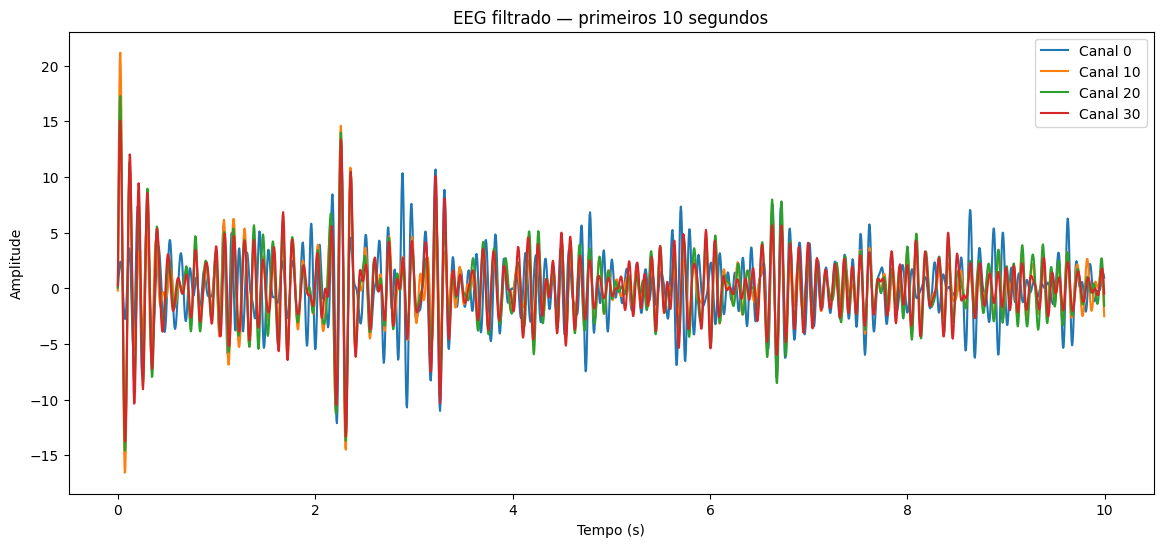

In [44]:
import matplotlib.pyplot as plt

idx_participante = 0
X = data_filtrada[idx_participante]

fs = fs_list[idx_participante]

tempo = np.arange(X.shape[0]) / fs

canais_para_plotar = [0, 10, 20, 30]

plt.figure(figsize=(14,6))

for canal in canais_para_plotar:
    plt.plot(
        tempo[:2000],
        X[:2000, canal],
        label=f"Canal {canal}"
    )

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.title("EEG filtrado — primeiros 10 segundos")
plt.legend()
plt.show()

# 13 - Inspecionar estrutura dos trials

In [45]:
idx = 0

mat = loadmat(
    files[idx],
    squeeze_me=True,
    struct_as_record=False
)

data = mat["data"]
mrk = mat["mrk"]

trial = data.trial
labels = data.y

print("Número de trials:", len(trial))

print("\nPrimeiros trials:")
print(trial[:10])

print("\nPrimeiros labels:")
print(labels[:10])

Número de trials: 600

Primeiros trials:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros labels:
[2 1 3 1 2 4 3 6 3 3]


# 14 - Calcular duração dos trials

In [46]:
trial_diff = np.diff(trial)

print("Primeiros tamanhos de trials:")
print(trial_diff[:10])

print("\nMédia:")
print(int(np.mean(trial_diff)))

print("\nMínimo:")
print(np.min(trial_diff))

print("\nMáximo:")
print(np.max(trial_diff))

Primeiros tamanhos de trials:
[1062  825 1063 1062  904  884 1062 1062  859 1062]

Média:
964

Mínimo:
762

Máximo:
1903


# 15 - Inspecionar estrutura dos eventos cue/target

In [47]:
print("Campos dentro de mrk.target_location:")

if hasattr(mrk.target_location, "_fieldnames"):
    print(mrk.target_location._fieldnames)
else:
    print("Não é struct")

Campos dentro de mrk.target_location:
['pos', 'toe', 'fs', 'y', 'className']


## 15.1 - Inspecionar conteúdo dos campos de target_location

In [48]:
for campo in mrk.target_location._fieldnames:
    valor = getattr(mrk.target_location, campo)

    print("\nCampo:", campo)
    print("Tipo:", type(valor))

    if hasattr(valor, "shape"):
        print("Shape:", valor.shape)

    if hasattr(valor, "__len__"):
        try:
            print("Primeiros valores:")
            print(valor[:20])
        except:
            pass


Campo: pos
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190 11252 12015
 13081 14127 15194 16135 17194 18256 19319 20381]

Campo: toe
Tipo: <class 'numpy.ndarray'>
Shape: (600,)
Primeiros valores:
[37 30 32 30 37 39 30 41 37 32 32 34 39 37 34 37 32 41 34 41]

Campo: fs
Tipo: <class 'int'>

Campo: y
Tipo: <class 'numpy.ndarray'>
Shape: (6, 600)
Primeiros valores:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [0 0 1 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

Campo: className
Tipo: <class 'numpy.ndarray'>
Shape: (6,)
Primeiros valores:
['target @1' 'target @2' 'target @3' 'target @4' 'target @5' 'target @6']


# 16 - Calcular delay entre cue e target

In [49]:
cue_pos = data.trial
target_pos = mrk.target_location.pos

print("Primeiros cue_pos:")
print(cue_pos[:10])

print("\nPrimeiros target_pos:")
print(target_pos[:10])

delay = target_pos - cue_pos

print("\nDelay entre cue e target em amostras:")
print(delay[:20])

print("\nDelay médio em segundos:")
print(np.mean(delay) / fs)

print("\nDelay mínimo em segundos:")
print(np.min(delay) / fs)

print("\nDelay máximo em segundos:")
print(np.max(delay) / fs)

Primeiros cue_pos:
[ 978 2040 2865 3928 4990 5894 6778 7840 8902 9761]

Primeiros target_pos:
[ 1407  2232  3295  4357  5261  6144  7207  8269  9127 10190]

Delay entre cue e target em amostras:
[429 192 430 429 271 250 429 429 225 429 429 129 429 412 433 308 425 429
 430 429]

Delay médio em segundos:
1.621925

Delay mínimo em segundos:
0.645

Delay máximo em segundos:
2.17


# 17 - Criar epochs alinhadas ao cue

Nesta etapa segmentamos o sinal EEG filtrado usando os instantes de cue
como referência temporal.

Cada epoch será extraída do intervalo entre:

cue → target

Esse intervalo representa o período em que o participante recebeu o cue
e manteve a atenção encoberta até o surgimento do target.

Cada epoch será armazenada como uma matriz:

[n_amostras × n_canais]

In [50]:
idx_participante = 0

X = data_filtrada[idx_participante]

cue_pos = data.trial
target_pos = mrk.target_location.pos
target_y = mrk.target_location.y

epochs_cue_target = []
labels_cue_target = []

for i in range(len(cue_pos)):

    inicio = cue_pos[i]
    fim = target_pos[i]

    if fim > inicio and fim <= X.shape[0]:

        epoch = X[inicio:fim, :]

        classe = np.argmax(target_y[:, i])

        epochs_cue_target.append(epoch)
        labels_cue_target.append(classe)

labels_cue_target = np.array(labels_cue_target)

print("Número de epochs criadas:", len(epochs_cue_target))
print("Número de labels:", len(labels_cue_target))

print("\nPrimeiras shapes das epochs:")

for i in range(5):
    print(f"Epoch {i}:", epochs_cue_target[i].shape)

print("\nPrimeiros labels:")
print(labels_cue_target[:10])

Número de epochs criadas: 600
Número de labels: 600

Primeiras shapes das epochs:
Epoch 0: (429, 62)
Epoch 1: (192, 62)
Epoch 2: (430, 62)
Epoch 3: (429, 62)
Epoch 4: (271, 62)

Primeiros labels:
[1 0 2 0 1 3 0 5 1 2]


# 18 - Padronizar tamanho das epochs usando delay mínimo

Como os intervalos cue→target variam entre trials,
definimos o tamanho da janela fixa com base no menor delay encontrado.

Isso garante que todas as epochs tenham o mesmo tamanho
sem remover trials.

A janela final será:

cue → cue + delay_mínimo

In [51]:
delay = target_pos - cue_pos

janela_amostras = int(np.min(delay))

print("Janela escolhida (amostras):", janela_amostras)
print("Janela escolhida (segundos):", janela_amostras / fs)

epochs_padronizadas = []
labels_padronizadas = []

for epoch, label in zip(epochs_cue_target, labels_cue_target):

    epoch_fixada = epoch[:janela_amostras, :]

    epochs_padronizadas.append(epoch_fixada)
    labels_padronizadas.append(label)

epochs_padronizadas = np.array(epochs_padronizadas)
labels_padronizadas = np.array(labels_padronizadas)

print("\nShape final das epochs:")
print(epochs_padronizadas.shape)

print("\nShape final dos labels:")
print(labels_padronizadas.shape)

print("\nTotal de trials mantidos:", len(epochs_padronizadas))

Janela escolhida (amostras): 129
Janela escolhida (segundos): 0.645

Shape final das epochs:
(600, 129, 62)

Shape final dos labels:
(600,)

Total de trials mantidos: 600


# 19 - ICA:

In [52]:
import mne
from mne.preprocessing import ICA

# 1. Preparando os metadados para o MNE
# Criamos uma lista com nomes genéricos para os 62 canais
ch_names = [f'EEG_{i:03d}' for i in range(62)]
ch_types = ['eeg'] * 62
info = mne.create_info(ch_names=ch_names, sfreq=200, ch_types=ch_types)

# 2. Convertendo NumPy Array para MNE Epochs
# IMPORTANTE: Transpomos de (600, 129, 62) para (600, 62, 129)
data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

# 3. Configurando o ICA
# 'n_components=20' é um bom ponto de partida para 62 canais
# 'method=fastica' é o padrão estável
ica = ICA(n_components=20, random_state=42, method='fastica')

# 4. Treinando o ICA nos dados
print("Iniciando o ajuste do ICA (isso pode levar alguns segundos)...")
ica.fit(epochs_mne)

print("\nICA ajustado com sucesso!")
print(f"Número de componentes encontrados: {ica.n_components_}")

Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Iniciando o ajuste do ICA (isso pode levar alguns segundos)...
Fitting ICA to data using 62 channels (please be patient, this may take a while)


/tmp/ipykernel_50095/2849279526.py:22: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_mne)


Selecting by number: 20 components
Fitting ICA took 7.4s.

ICA ajustado com sucesso!
Número de componentes encontrados: 20


Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Fitting ICA to data using 62 channels (please be patient, this may take a while)


/tmp/ipykernel_50095/32964003.py:22: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(epochs_mne)


Selecting by number: 20 components
Fitting ICA took 8.8s.
Gerando mapas topográficos... Procure por componentes com picos frontais (olhos).


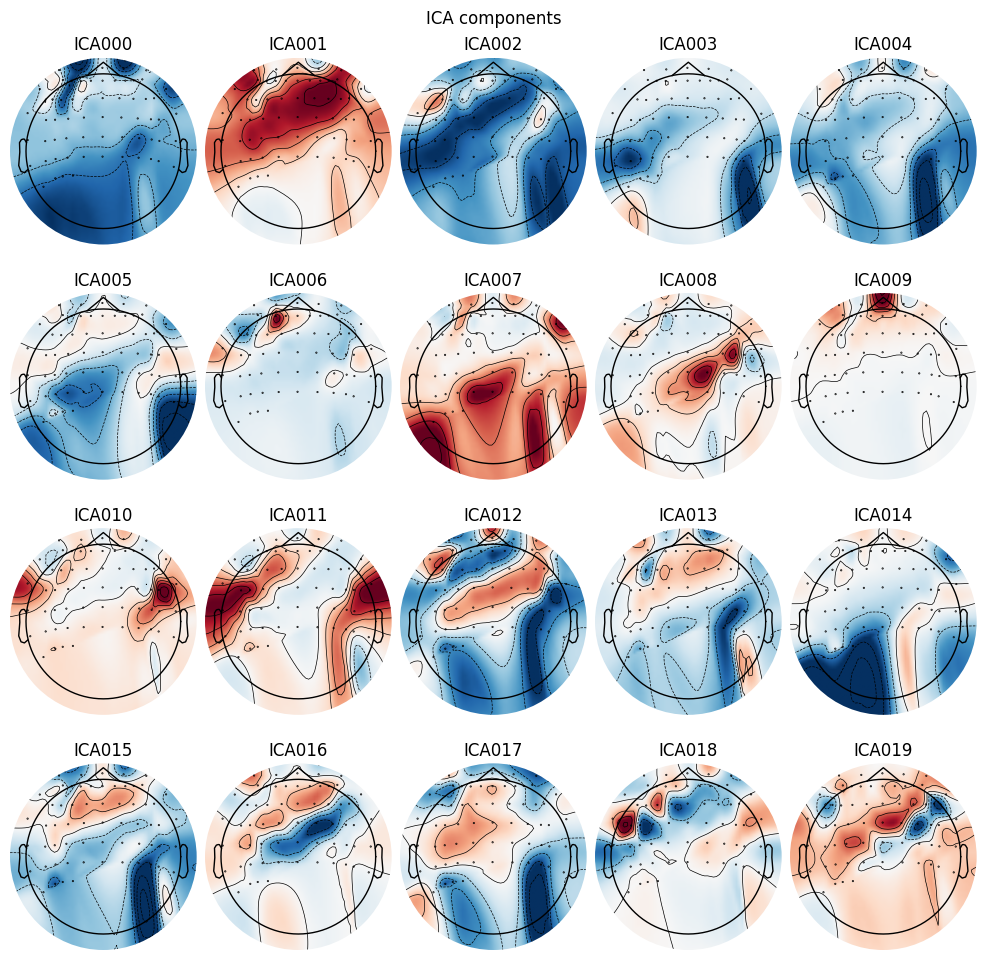

Not setting metadata
600 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


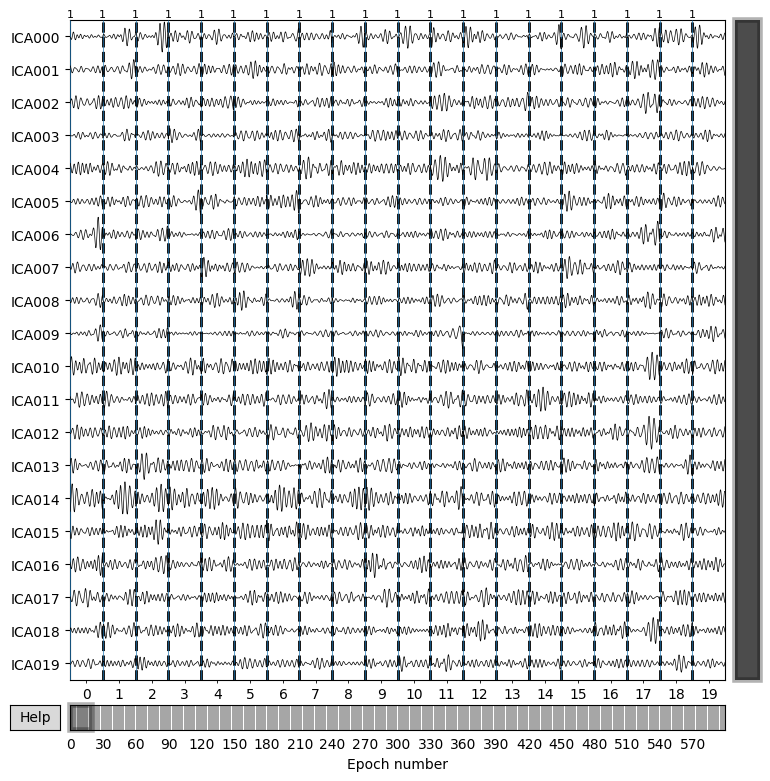

Aplicando limpeza: removendo componentes [0, 1]
Applying ICA to Epochs instance
    Transforming to ICA space (20 components)
    Zeroing out 2 ICA components
    Projecting back using 62 PCA components

PROCESSO ICA CONCLUÍDO
Shape resultante: (600, 129, 62)


In [53]:
import mne
import numpy as np
from mne.preprocessing import ICA

# 1. Obter nomes padrão do sistema 10-20 para os 62 canais
# Isso é um "truque" para que o MNE saiba onde desenhar cada ponto
montage_std = mne.channels.make_standard_montage('standard_1020')
std_ch_names = montage_std.ch_names[:62] # Pegamos os primeiros 62 nomes padrão

# 2. Criar Info e aplicar a Montagem
info = mne.create_info(ch_names=std_ch_names, sfreq=200, ch_types='eeg')
info.set_montage(montage_std)

# 3. Criar o objeto MNE Epochs
# Transpomos de (600, 129, 62) para (600, 62, 129)
data_mne = epochs_padronizadas.transpose(0, 2, 1)
epochs_mne = mne.EpochsArray(data_mne, info)

# 4. Ajustar (Fit) o ICA
# O aviso de High-pass pode aparecer, mas como seus dados já estão filtrados, pode prosseguir
ica = ICA(n_components=20, random_state=42, method='fastica')
ica.fit(epochs_mne)

# 5. Visualização (Agora os mapas devem aparecer!)
print("Gerando mapas topográficos... Procure por componentes com picos frontais (olhos).")
ica.plot_components()
ica.plot_sources(epochs_mne)

# =================================================================
# PARTE DE LIMPEZA (Edite os números em 'exclude' após ver os gráficos)
# =================================================================
# Geralmente os olhos são os componentes 0, 1 ou 2.
ica.exclude = [0, 1]

print(f"Aplicando limpeza: removendo componentes {ica.exclude}")
epochs_limpas = ica.apply(epochs_mne.copy())

# 6. Conversão final para NumPy (Voltando ao seu formato original)
epochs_padronizadas_clean = epochs_limpas.get_data().transpose(0, 2, 1)

print("\n" + "="*30)
print("PROCESSO ICA CONCLUÍDO")
print(f"Shape resultante: {epochs_padronizadas_clean.shape}")
print("="*30)

# 20 - Extração da Potência Alfa via Método de Welch:

Nessa etapa, será realizada a extração de características espectrais dos sinais de EEG processados. Dessa forma, utilizamos o Método de Welch para calcular a Densidade Espectral de Potência (PSD) em cada um dos 62 canais de forma independente.  

In [54]:
import numpy as np
from scipy.signal import welch

# 1. Configurações base
fs = 200

# Selecionando exatamente os 32 canais posteriores (índices 30 a 62)
# Isso garante que o shape final seja (600, 32)
indices_canais = list(range(30, 62))
n_canais_selecionados = len(indices_canais)

X_welch_raw = []

print(f"Calculando PSD via Welch para {len(epochs_padronizadas_clean)} trials...")
print(f"Foco: {n_canais_selecionados} canais posteriores selecionados.")

for trial in epochs_padronizadas_clean:
    trial_psds = []

    # Calculamos o PSD apenas para os canais do intervalo definido
    for ch_idx in indices_canais:
        # nperseg=256 e noverlap=128 para reduzir a variância (suavizar ruído)
        freqs, psd = welch(trial[:, ch_idx],
                           fs=fs,
                           nperseg=256,
                           noverlap=128)
        trial_psds.append(psd)

    X_welch_raw.append(trial_psds)

# Convertendo para array NumPy 3D (Trials, Canais, Frequências)
X_welch_raw = np.array(X_welch_raw)

Calculando PSD via Welch para 600 trials...
Foco: 32 canais posteriores selecionados.


/tmp/ipykernel_50095/331697542.py:23: UserWarning: nperseg=256 is greater than signal length max(len(x), len(y)) = 129, using nperseg = 129
  freqs, psd = welch(trial[:, ch_idx],


# 21 - Converter epochs para matriz 2D

Nesta etapa convertemos as epochs tridimensionais:

[n_trials × n_amostras × n_canais]

em uma matriz bidimensional:

[n_trials × n_features]

Cada epoch será transformada em um vetor único,
permitindo o uso de métodos como PCA e classificadores.

In [55]:
# COMPRESSÃO PARA O SVM (Transformando 3D em 2D)
# =================================================================
# 1. Encontramos os índices das frequências da Banda Alfa (8 a 14 Hz)
idx_alfa = np.where((freqs >= 8) & (freqs <= 14))[0]

# 2. Tiramos a média da banda alfa para cada um dos 32 canais
X_features_welch = np.mean(X_welch_raw[:, :, idx_alfa], axis=-1)

# 3. Aplicamos o Log10 com constante de estabilidade (evita -inf)
X_features_welch = np.log10(X_features_welch + 1e-10)

print("\n" + "="*40)
print("PSD CALCULADO (WELCH SUAVIZADO)")
print(f"Shape bruto: {X_welch_raw.shape}")
print(f"Shape final para o SVM: {X_features_welch.shape}")
print(f"Canais processados: {n_canais_selecionados} (Posteriores)")
print("="*40)


PSD CALCULADO (WELCH SUAVIZADO)
Shape bruto: (600, 32, 65)
Shape final para o SVM: (600, 32)
Canais processados: 32 (Posteriores)


# 22 - Padronizar os dados (z-score)

Nesta etapa padronizamos cada feature para ter:

média = 0  
desvio padrão = 1  

Essa transformação é necessária antes da aplicação do PCA, pois padroniza os valores de potência da banda Alfa extraídos no bloco anterior e garante que a potência de todos os eletrodos contribua de forma equilibrada para o cálculo da matriz de covariância, evitando que canais com amplitudes maiores dominem a análise das direções principais de variância espacial.

In [56]:
from sklearn.preprocessing import StandardScaler

scaler_welch = StandardScaler()
X_padronizado_welch = scaler_welch.fit_transform(X_features_welch)

print("Shape após padronização:")
print(X_padronizado_welch.shape)

print("Média aproximada (primeiras features):")
print(np.mean(X_padronizado_welch[:, :5], axis=0))

print("Desvio padrão aproximado (primeiras features):")
print(np.std(X_padronizado_welch[:, :5], axis=0))

Shape após padronização:
(600, 32)
Média aproximada (primeiras features):
[-5.49467879e-16  2.77185682e-16  1.06914477e-15 -8.93729535e-17
  6.67521594e-16]
Desvio padrão aproximado (primeiras features):
[1. 1. 1. 1. 1.]


# 23 - Classificador SVM pós extração de atributos via Welch:

Treinando modelo Binário...
Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...

RESUMO DE PERFORMANCE (BASELINE)
Dados de Entrada: Welch + Log10 (Banda Alfa | 32 Canais)
Melhores parâmetros Multiclasse: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Acurácia Binária (Direção 0 vs 1): 61.77%
Acurácia Multiclasse (Todas as 6): 20.17%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


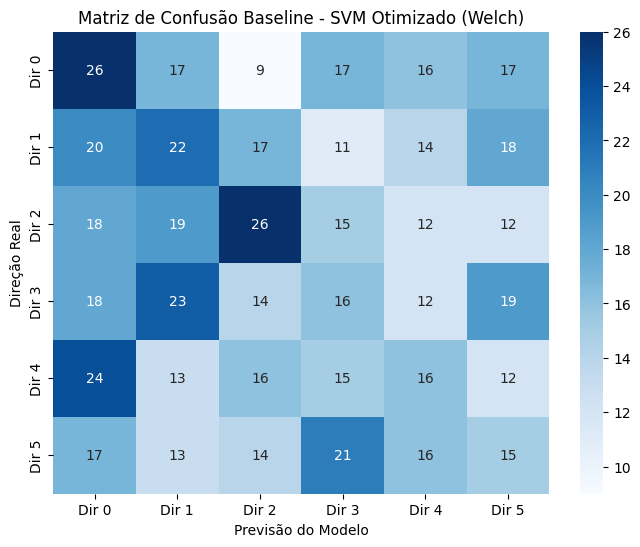

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

# --- 1. GARANTIA DOS DADOS DO WELCH ---
scaler = StandardScaler()
X_final = scaler.fit_transform(X_features_welch)
y_final = labels_padronizadas

# Configuração da Validação Cruzada (Padrão UFABC)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 2. OTIMIZAÇÃO BINÁRIA (Mantendo os ~60%) ---
# Para o binário (0 vs 1), a acurácia normal funciona perfeitamente.
param_grid_bin = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}

print("Treinando modelo Binário...")
grid_bin = GridSearchCV(SVC(class_weight='balanced', random_state=42),
                        param_grid_bin, cv=cv, scoring='accuracy', n_jobs=-1)

p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_bin.fit(X_bin, y_bin)
melhor_modelo_bin = grid_bin.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()


# --- 3. OTIMIZAÇÃO MULTICLASSE  ---
# usamos 'f1_macro' para PROIBIR o SVM de ignorar classes.
# Também forçamos o formato 'ovo' (One-Vs-One) para que ele crie duelos diretos entre todas as classes.
param_grid_multi = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf'] # Mantemos apenas RBF no multiclasse para evitar loops de convergência
}

print("Treinando modelo Multiclasse com proteção anti-colapso (F1-Macro)...")
grid_multi = GridSearchCV(SVC(class_weight='balanced', decision_function_shape='ovo', random_state=42),
                          param_grid_multi, cv=cv, scoring='f1_macro', n_jobs=-1)

grid_multi.fit(X_final, y_final)
melhor_modelo_multi = grid_multi.best_estimator_

# Voltamos a medir a acurácia normal (total de acertos) apenas para a exibição no relatório
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv, scoring='accuracy').mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)


# --- 4. RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print(f"RESUMO DE PERFORMANCE (BASELINE)")
print("="*50)
print(f"Dados de Entrada: Welch + Log10 (Banda Alfa | {X_final.shape[1]} Canais)")
print(f"Melhores parâmetros Multiclasse: {grid_multi.best_params_}")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)


# --- 5. PLOT DA MATRIZ AZUL ---
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)

sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Baseline - SVM Otimizado (Welch)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

# 24 - Aplicando o CSP:
Para obter um valor de acurácia idêntico ao proposto pelo artigo,
é necessário utilizar a extração de atributos do CSP

In [58]:
import numpy as np
from mne.decoding import CSP
# =====================================================================
# 1. PREPARAÇÃO DOS DADOS
# =====================================================================
X_time = np.transpose(epochs_padronizadas_clean, (0, 2, 1))
y = labels_padronizadas
# =====================================================================
# 2. CONFIGURAÇÃO CSP "ELITE"
# =====================================================================
# Adicionamos 'rank' para garantir que canais redundantes não sujem a matriz
# O parâmetro 'cov_estimator' garante a maior robustez estatística possível
csp = CSP(n_components=10,
          reg='ledoit_wolf',
          rank='full',
          log=True,
          norm_trace=False)

print("Extraindo componentes espaciais otimizados...")
X_csp = csp.fit_transform(X_time, y)

# =====================================================================
# 3. CONEXÃO COM O SVM
# =====================================================================
X_features = X_csp
# Dica: No seu código do SVM, o print ainda diz "Welch + Log10".
# Se quiser deixar o relatório correto, mude para:
# print(f"Dados de Entrada: CSP Espacial (10 Componentes)")
print("\n" + "="*40)
print("EXTRAÇÃO CSP FINALIZADA")
print(f"Shape para o SVM: {X_features.shape}")
print("Pode rodar o classificador.")
print("="*40)

Extraindo componentes espaciais otimizados...
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.

EXTRAÇÃO CSP FINALIZADA
Shape para o SVM: (600, 10)
Pode rodar o classificador.


# 25 - Aplicando o classificador: Após utilizar o CSP, mandamos para o SVM

Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...
Melhores parâmetros binários: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Melhores parâmetros multiclasse: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Dados de Entrada: CSP + Log10 Banda Alfa (SVM) | 10 Canais Originais)
Acurácia Binária (Direção 0 vs 1): 73.02%
Acurácia Multiclasse (Todas as 6): 34.67%
Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)


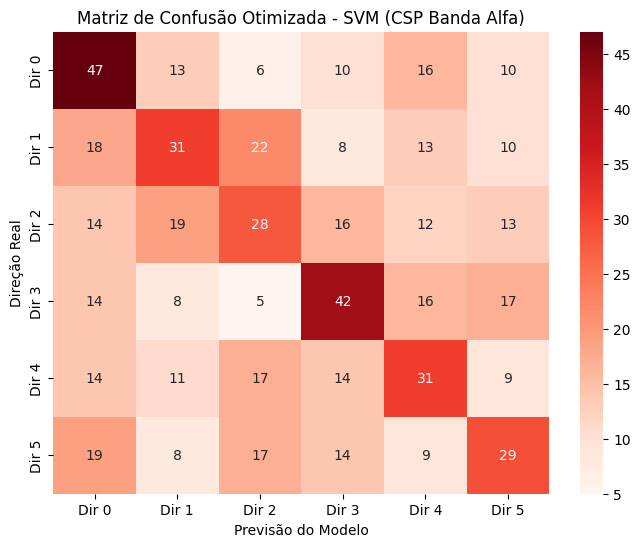

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix

# Usando X_features para garantir a riqueza espacial dos 32 canais
X_final = X_features
y_final = labels_padronizadas

# Configuração da Validação Cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- OTIMIZAÇÃO (Grid Search) ---
# Vamos testar várias configurações para ver qual lida melhor com o "ruído" dos 32 canais
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear'] # Adicionando o linear, que às vezes é melhor para BCI multiclasse
}

print("Iniciando busca pelos melhores parâmetros (isso pode levar alguns segundos)...")
grid_search = GridSearchCV(SVC(class_weight='balanced', random_state=42), param_grid, cv=cv, scoring='accuracy')

# --- PARTE A: AVALIAÇÃO BINÁRIA (Melhor Par: 0 vs 1) ---
p1, p2 = 0, 1
mask = np.isin(y_final, [p1, p2])
X_bin = X_final[mask]
y_bin = np.where(y_final[mask] == p1, 0, 1)

grid_search.fit(X_bin, y_bin)
melhor_modelo_bin = grid_search.best_estimator_
acc_binaria = cross_val_score(melhor_modelo_bin, X_bin, y_bin, cv=cv).mean()
print(f"Melhores parâmetros binários: {grid_search.best_params_}")


# --- PARTE B: AVALIAÇÃO MULTICLASSE (1 em 6) ---
grid_search.fit(X_final, y_final)
melhor_modelo_multi = grid_search.best_estimator_
acc_multi = cross_val_score(melhor_modelo_multi, X_final, y_final, cv=cv).mean()
y_pred_multi = cross_val_predict(melhor_modelo_multi, X_final, y_final, cv=cv)
print(f"Melhores parâmetros multiclasse: {grid_search.best_params_}")


# --- RELATÓRIO DE SAÍDA FINAL ---
print("\n" + "="*50)
print("="*50)
print(f"Dados de Entrada: CSP + Log10 Banda Alfa (SVM) | {X_final.shape[1]} Canais Originais)")
print(f"Acurácia Binária (Direção {p1} vs {p2}): {acc_binaria*100:.2f}%")
print(f"Acurácia Multiclasse (Todas as 6): {acc_multi*100:.2f}%")
print(f"Nível de Chance: Binário (50.00%) | Multiclasse (16.66%)")
print("="*50)

# Plot da Matriz Multiclasse
plt.figure(figsize=(8, 6))
matriz_confusao = confusion_matrix(y_final, y_pred_multi)
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Reds',
            xticklabels=[f'Dir {i}' for i in range(6)],
            yticklabels=[f'Dir {i}' for i in range(6)])
plt.title('Matriz de Confusão Otimizada - SVM (CSP Banda Alfa)')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Direção Real')
plt.show()

# 26 - Teste de Janelas Temporais Adaptativas com CSP + SVM

Nesta etapa, mantemos a mesma lógica utilizada no pipeline do Caio:

1. os sinais são segmentados em diferentes tamanhos de janela temporal;
2. os dados são reorganizados no formato esperado pelo CSP;
3. o CSP é ajustado e transforma as épocas em componentes espaciais;
4. os componentes CSP são enviados para o classificador SVM;
5. a acurácia é comparada entre diferentes tamanhos de janela.

A diferença desta etapa é que avaliamos várias janelas temporais para estudar o compromisso entre **tempo de decisão** e **desempenho de classificação**. Essa análise representa a contribuição própria do grupo para uma aplicação de tecnologia assistiva, em que uma BCI precisa decidir rapidamente se a atenção do usuário permaneceu ou se deslocou.

In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


def criar_epochs_por_janela(X_continuo, cue_pos, target_y, fs, janela_s):
    """
    Cria epochs com tamanho fixo definido em segundos, sempre alinhadas ao cue.

    Parâmetros
    ----------
    X_continuo : array, shape (amostras, canais)
        Sinal EEG contínuo já filtrado.
    cue_pos : array, shape (n_trials,)
        Posições temporais dos cues em amostras.
    target_y : array, shape (n_classes, n_trials)
        Matriz one-hot das classes/direções.
    fs : int ou float
        Frequência de amostragem.
    janela_s : float
        Tamanho da janela em segundos.

    Retorna
    -------
    epochs : array, shape (n_trials_validos, janela_amostras, canais)
    labels : array, shape (n_trials_validos,)
    """

    janela_amostras = int(fs * janela_s)

    epochs = []
    labels = []

    for i, inicio in enumerate(cue_pos):
        fim = inicio + janela_amostras

        if fim <= X_continuo.shape[0]:
            epoch = X_continuo[inicio:fim, :]
            classe = np.argmax(target_y[:, i])

            epochs.append(epoch)
            labels.append(classe)

    epochs = np.array(epochs)
    labels = np.array(labels)

    return epochs, labels


def avaliar_csp_svm_logica_caio(epochs, y, titulo, n_components=10):
    """
    Avalia CSP + SVM seguindo a mesma lógica operacional usada no código do Caio:

    - CSP é aplicado primeiro ao conjunto de epochs;
    - a saída do CSP é usada como entrada do SVM;
    - o SVM é otimizado com GridSearchCV;
    - a predição final é obtida por validação cruzada.

    Observação metodológica: esta estratégia reproduz a lógica usada pelo grupo/artigo.
    Para uma validação mais rígida, CSP e SVM deveriam ser encapsulados juntos dentro de
    um Pipeline do scikit-learn. Aqui mantemos a lógica do Caio para comparação direta.
    """

    print("=" * 70)
    print(titulo)
    print("=" * 70)

    epochs = np.asarray(epochs, dtype=float)
    y = np.asarray(y, dtype=int)

    # MNE CSP espera formato: (n_epochs, n_channels, n_times)
    X_time = np.transpose(epochs, (0, 2, 1))

    print("Shape epochs:", epochs.shape)
    print("Shape X entrada CSP:", X_time.shape)
    print("Shape y:", y.shape)

    csp = CSP(
        n_components=n_components,
        reg='ledoit_wolf',
        rank='full',
        log=True,
        norm_trace=False
    )

    X_csp = csp.fit_transform(X_time, y)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_grid = {
        'C': [0.1, 1, 10, 50, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }

    grid_search = GridSearchCV(
        SVC(class_weight='balanced', random_state=42),
        param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X_csp, y)
    melhor_modelo = grid_search.best_estimator_

    acc = cross_val_score(melhor_modelo, X_csp, y, cv=cv, scoring='accuracy').mean()
    y_pred = cross_val_predict(melhor_modelo, X_csp, y, cv=cv)
    cm = confusion_matrix(y, y_pred)

    print("Melhores parâmetros:", grid_search.best_params_)
    print(f"Acurácia: {acc * 100:.2f}%")
    print("Nível de chance multiclasse: 16.67%")
    print("Relatório de classificação:")
    print(classification_report(y, y_pred, digits=3))

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Reds',
        xticklabels=[f'Dir {i}' for i in sorted(np.unique(y))],
        yticklabels=[f'Dir {i}' for i in sorted(np.unique(y))]
    )
    plt.title(titulo)
    plt.xlabel('Previsão do Modelo')
    plt.ylabel('Classe real')
    plt.show()

    return {
        'titulo': titulo,
        'accuracy': acc,
        'cm': cm,
        'y_pred': y_pred,
        'X_csp': X_csp,
        'melhor_modelo': melhor_modelo,
        'melhores_parametros': grid_search.best_params_
    }


## 26.1 - Execução do teste de janelas

Nesta célula, testamos diferentes tamanhos de janela temporal. Para uma aplicação assistiva online, janelas menores reduzem a latência da decisão, enquanto janelas maiores tendem a aumentar a estabilidade do sinal e a acurácia.

As janelas testadas são:

- 0.5 s
- 1.0 s
- 2.0 s
- 3.0 s

O objetivo é identificar qual janela oferece o melhor compromisso entre resposta rápida e desempenho de classificação.

CSP + SVM — Janela 0.50 s
Shape epochs: (600, 100, 62)
Shape X entrada CSP: (600, 62, 100)
Shape y: (600,)
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Acurácia: 46.00%
Nível de chance multiclasse: 16.67%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.436     0.402     0.418       102
           1      0.341     0.284     0.310       102
           2      0.477     0.500     0.488       102
           3      0.509     0.549     0.528       102
           4      0.474     0.656     0.550        9

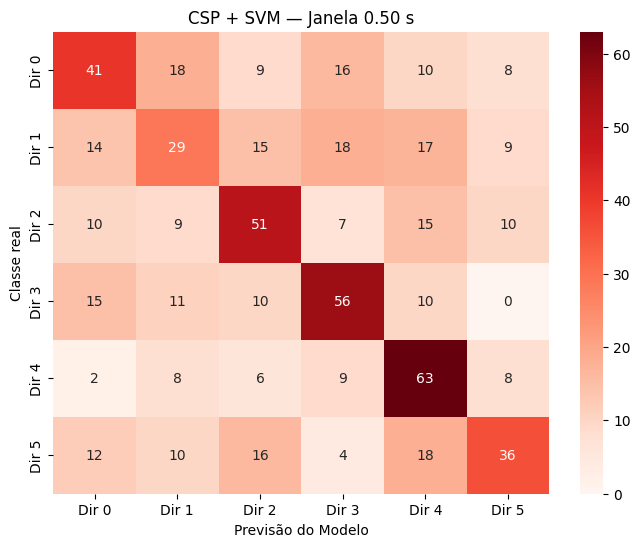

CSP + SVM — Janela 1.00 s
Shape epochs: (600, 200, 62)
Shape X entrada CSP: (600, 62, 200)
Shape y: (600,)
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Acurácia: 36.50%
Nível de chance multiclasse: 16.67%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.414     0.471     0.440       102
           1      0.333     0.235     0.276       102
           2      0.333     0.382     0.356       102
           3      0.339     0.363     0.351       102
           4      0.395     0.490     0.437        

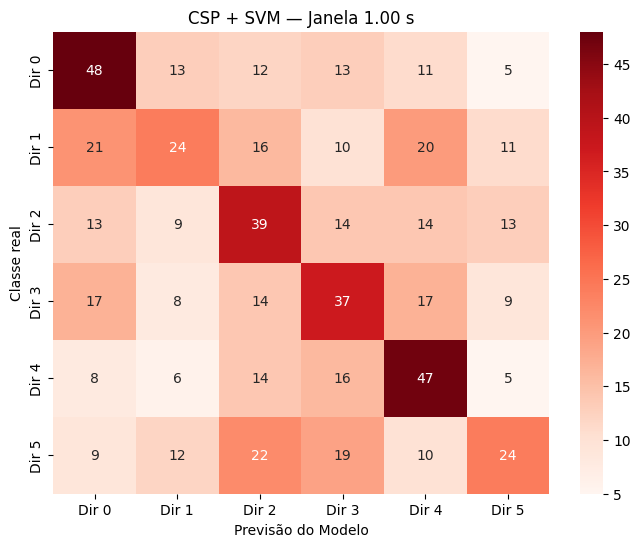

CSP + SVM — Janela 2.00 s
Shape epochs: (600, 400, 62)
Shape X entrada CSP: (600, 62, 400)
Shape y: (600,)
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Acurácia: 30.17%
Nível de chance multiclasse: 16.67%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.305     0.284     0.294       102
           1      0.308     0.275     0.290       102
           2      0.284     0.265     0.274       102
           3      0.295     0.480     0.366       102
           4      0.333     0.188     0.240 

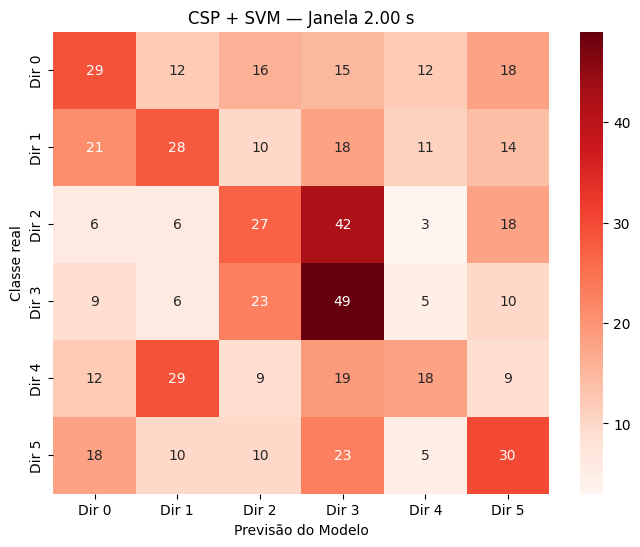

CSP + SVM — Janela 3.00 s
Shape epochs: (600, 600, 62)
Shape X entrada CSP: (600, 62, 600)
Shape y: (600,)
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Estimating class=2 covariance using LEDOIT_WOLF
Done.
Estimating class=3 covariance using LEDOIT_WOLF
Done.
Estimating class=4 covariance using LEDOIT_WOLF
Done.
Estimating class=5 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Acurácia: 34.50%
Nível de chance multiclasse: 16.67%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.330     0.314     0.322       102
           1      0.379     0.382     0.380       102
           2      0.340     0.324     0.332       102
           3      0.326     0.441     0.375       102
           4      0.370     0.312     0.339       

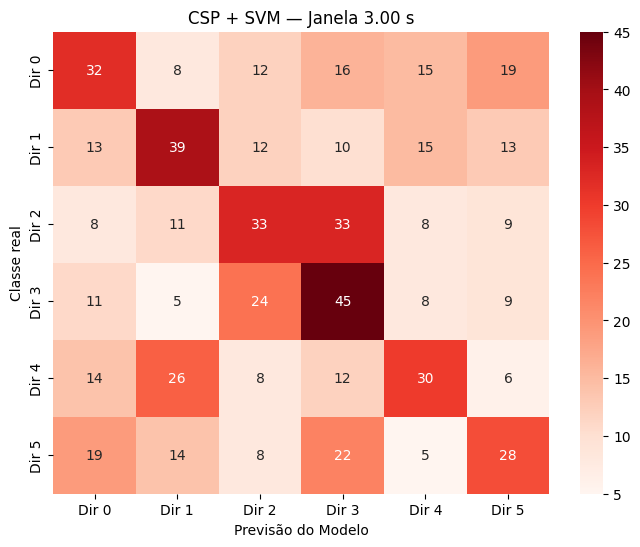

[{'janela_s': 0.5,
  'n_trials': 600,
  'accuracy': np.float64(0.45999999999999996)},
 {'janela_s': 1.0,
  'n_trials': 600,
  'accuracy': np.float64(0.36499999999999994)},
 {'janela_s': 2.0,
  'n_trials': 600,
  'accuracy': np.float64(0.3016666666666667)},
 {'janela_s': 3.0,
  'n_trials': 600,
  'accuracy': np.float64(0.34500000000000003)}]

In [61]:
janelas_teste = [0.5, 1.0, 2.0, 3.0]
resultados_janelas = []
resultados_completos_janelas = {}

# Mantemos o mesmo participante e as mesmas marcações usadas anteriormente.
idx_participante = 0
X_continuo = data_filtrada[idx_participante]
cue_pos = data.trial
target_y = mrk.target_location.y
fs = int(data.fs)

for janela_s in janelas_teste:
    epochs_janela, labels_janela = criar_epochs_por_janela(
        X_continuo=X_continuo,
        cue_pos=cue_pos,
        target_y=target_y,
        fs=fs,
        janela_s=janela_s
    )

    resultado = avaliar_csp_svm_logica_caio(
        epochs=epochs_janela,
        y=labels_janela,
        titulo=f'CSP + SVM — Janela {janela_s:.2f} s',
        n_components=10
    )

    resultados_completos_janelas[janela_s] = resultado
    resultados_janelas.append({
        'janela_s': janela_s,
        'n_trials': len(labels_janela),
        'accuracy': resultado['accuracy']
    })

resultados_janelas

## 26.2 - Comparação do desempenho por janela temporal

Após testar diferentes tamanhos de janela, comparamos as acurácias obtidas. A melhor janela é aquela que maximiza a acurácia, mas a interpretação para uma BCI assistiva deve considerar também a latência: uma janela muito longa pode atrasar a resposta do sistema.

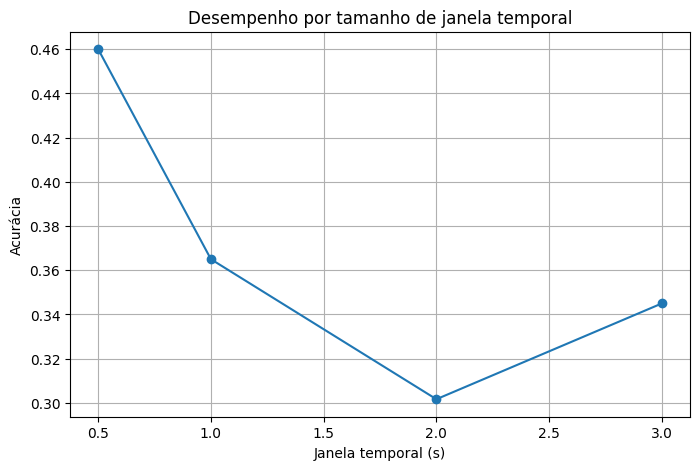

Melhor janela por acurácia: 0.5 s
Acurácia: 0.45999999999999996
Resumo das janelas:
Janela 0.50s | Trials: 600 | Acurácia: 46.00%
Janela 1.00s | Trials: 600 | Acurácia: 36.50%
Janela 2.00s | Trials: 600 | Acurácia: 30.17%
Janela 3.00s | Trials: 600 | Acurácia: 34.50%


In [62]:
janelas = [r['janela_s'] for r in resultados_janelas]
accuracies = [r['accuracy'] for r in resultados_janelas]

melhor_idx = int(np.argmax(accuracies))
melhor_janela = janelas[melhor_idx]
melhor_acc = accuracies[melhor_idx]

plt.figure(figsize=(8, 5))
plt.plot(janelas, accuracies, marker='o')
plt.xlabel('Janela temporal (s)')
plt.ylabel('Acurácia')
plt.title('Desempenho por tamanho de janela temporal')
plt.grid(True)
plt.show()

print("Melhor janela por acurácia:", melhor_janela, "s")
print("Acurácia:", melhor_acc)

print("Resumo das janelas:")
for r in resultados_janelas:
    print(f"Janela {r['janela_s']:.2f}s | Trials: {r['n_trials']} | Acurácia: {r['accuracy']*100:.2f}%")

## 26.3 - Janelas temporais adaptativas no problema binário

Nesta etapa repetimos o teste de janelas temporais, mas agora na formulação binária usada anteriormente no pipeline CSP + SVM.

A formulação binária reduz o problema de 6 direções para apenas duas classes. No código abaixo, mantemos a mesma lógica já usada anteriormente no notebook:

- Direção 0
- Direção 1

Essa formulação é útil porque representa um caso mais simples e mais próximo de uma aplicação assistiva inicial, na qual o sistema precisa distinguir entre dois estados ou comandos possíveis. Para uma aplicação de vídeo que pausa quando há desvio de atenção, essa mesma estrutura poderia ser adaptada futuramente para:

- atenção mantida na região-alvo
- atenção desviada da região-alvo

Aqui, o objetivo imediato é verificar qual tamanho de janela temporal oferece melhor desempenho no problema binário, mantendo o mesmo fluxo operacional do Caio:

1. segmentação por janela;
2. seleção das classes binárias;
3. aplicação do CSP;
4. classificação com SVM;
5. comparação da acurácia entre janelas.


In [63]:
def avaliar_csp_svm_binario_logica_caio(epochs, y, p1=0, p2=1, titulo="CSP + SVM binário", n_components=10):
    """
    Avalia CSP + SVM em formulação binária, seguindo a lógica operacional do Caio.

    O procedimento seleciona apenas duas classes do vetor y, transforma essas classes
    em rótulos binários 0 e 1, aplica CSP no conjunto resultante e avalia o SVM com
    validação cruzada estratificada.

    Parâmetros
    ----------
    epochs : array, shape (n_trials, n_amostras, n_canais)
        Épocas de EEG já filtradas e segmentadas.
    y : array, shape (n_trials,)
        Labels multiclasses originais.
    p1, p2 : int
        Classes escolhidas para o problema binário.
    titulo : str
        Título usado nos prints e na matriz de confusão.
    n_components : int
        Número de componentes CSP.
    """

    print("=" * 70)
    print(titulo)
    print("=" * 70)

    epochs = np.asarray(epochs, dtype=float)
    y = np.asarray(y, dtype=int)

    mask = np.isin(y, [p1, p2])
    epochs_bin = epochs[mask]
    y_bin = np.where(y[mask] == p1, 0, 1)

    print("Classes usadas:", p1, "vs", p2)
    print("Shape epochs binárias:", epochs_bin.shape)
    print("Shape labels binárias:", y_bin.shape)
    print("Distribuição das classes binárias:", np.bincount(y_bin))

    # MNE CSP espera formato: (n_epochs, n_channels, n_times)
    X_time = np.transpose(epochs_bin, (0, 2, 1))

    csp = CSP(
        n_components=n_components,
        reg='ledoit_wolf',
        rank='full',
        log=True,
        norm_trace=False
    )

    X_csp = csp.fit_transform(X_time, y_bin)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    param_grid = {
        'C': [0.1, 1, 10, 50, 100],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1],
        'kernel': ['rbf', 'linear']
    }

    grid_search = GridSearchCV(
        SVC(class_weight='balanced', random_state=42),
        param_grid,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid_search.fit(X_csp, y_bin)
    melhor_modelo = grid_search.best_estimator_

    acc = cross_val_score(melhor_modelo, X_csp, y_bin, cv=cv, scoring='accuracy').mean()
    y_pred = cross_val_predict(melhor_modelo, X_csp, y_bin, cv=cv)
    cm = confusion_matrix(y_bin, y_pred)

    print("Melhores parâmetros:", grid_search.best_params_)
    print(f"Acurácia binária: {acc * 100:.2f}%")
    print("Nível de chance binário: 50.00%")
    print("Relatório de classificação:")
    print(classification_report(y_bin, y_pred, digits=3))

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[f'Dir {p1}', f'Dir {p2}'],
        yticklabels=[f'Dir {p1}', f'Dir {p2}']
    )
    plt.title(titulo)
    plt.xlabel('Previsão do Modelo')
    plt.ylabel('Classe real')
    plt.show()

    return {
        'titulo': titulo,
        'accuracy': acc,
        'cm': cm,
        'y_pred': y_pred,
        'X_csp': X_csp,
        'melhor_modelo': melhor_modelo,
        'melhores_parametros': grid_search.best_params_,
        'p1': p1,
        'p2': p2
    }


CSP + SVM Binário — Janela 0.50 s — Dir 0 vs Dir 1
Classes usadas: 0 vs 1
Shape epochs binárias: (204, 100, 62)
Shape labels binárias: (204,)
Distribuição das classes binárias: [102 102]
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 1, 'gamma': 'auto', 'kernel': 'rbf'}
Acurácia binária: 93.63%
Nível de chance binário: 50.00%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.949     0.922     0.935       102
           1      0.924     0.951     0.937       102

    accuracy                          0.936       204
   macro avg      0.937     0.936     0.936       204
weighted avg      0.937     0.936     0.936       204



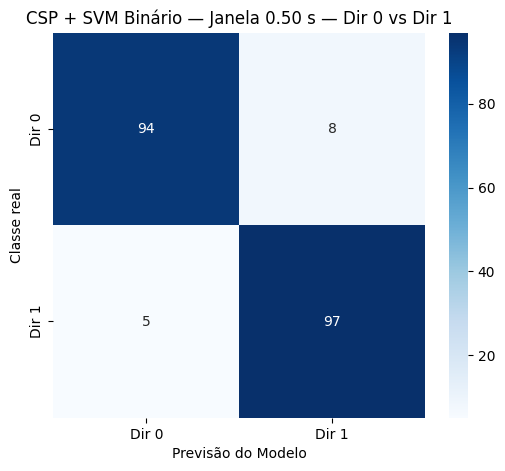

CSP + SVM Binário — Janela 1.00 s — Dir 0 vs Dir 1
Classes usadas: 0 vs 1
Shape epochs binárias: (204, 200, 62)
Shape labels binárias: (204,)
Distribuição das classes binárias: [102 102]
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Acurácia binária: 95.59%
Nível de chance binário: 50.00%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.960     0.951     0.956       102
           1      0.951     0.961     0.956       102

    accuracy                          0.956       204
   macro avg      0.956     0.956     0.956       204
weighted avg      0.956     0.956     0.956       204



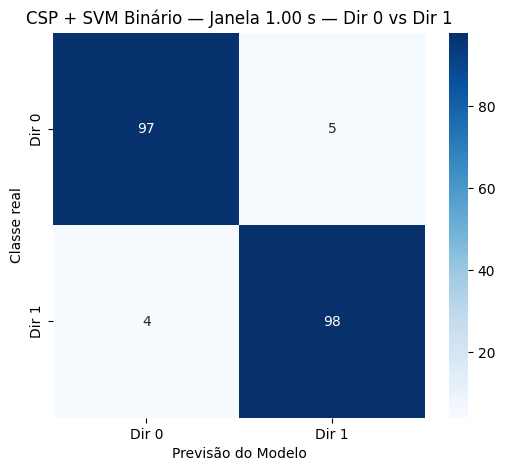

CSP + SVM Binário — Janela 2.00 s — Dir 0 vs Dir 1
Classes usadas: 0 vs 1
Shape epochs binárias: (204, 400, 62)
Shape labels binárias: (204,)
Distribuição das classes binárias: [102 102]
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Acurácia binária: 96.57%
Nível de chance binário: 50.00%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.961     0.971     0.966       102
           1      0.970     0.961     0.966       102

    accuracy                          0.966       204
   macro avg      0.966     0.966     0.966       204
weighted avg      0.966     0.966     0.966       204



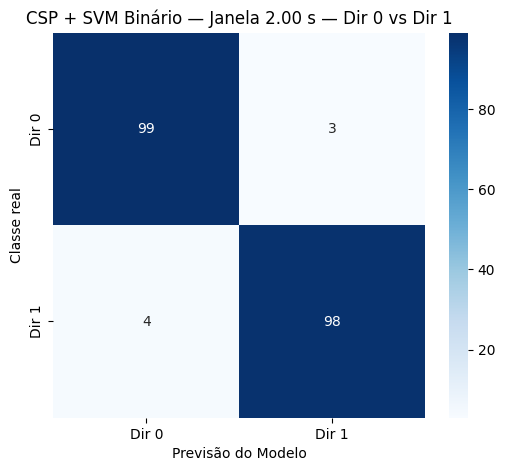

CSP + SVM Binário — Janela 3.00 s — Dir 0 vs Dir 1
Classes usadas: 0 vs 1
Shape epochs binárias: (204, 600, 62)
Shape labels binárias: (204,)
Distribuição das classes binárias: [102 102]
Computing rank from data with rank='full'
    data: rank 62 from info
Reducing data rank from 62 -> 62
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Melhores parâmetros: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Acurácia binária: 95.11%
Nível de chance binário: 50.00%
Relatório de classificação:
              precision    recall  f1-score   support

           0      0.960     0.941     0.950       102
           1      0.942     0.961     0.951       102

    accuracy                          0.951       204
   macro avg      0.951     0.951     0.951       204
weighted avg      0.951     0.951     0.951       204



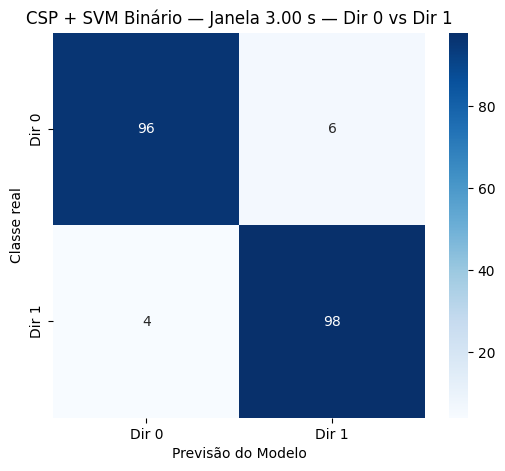

[{'janela_s': 0.5,
  'n_trials': 600,
  'accuracy': np.float64(0.9363414634146341),
  'p1': 0,
  'p2': 1},
 {'janela_s': 1.0,
  'n_trials': 600,
  'accuracy': np.float64(0.9558536585365853),
  'p1': 0,
  'p2': 1},
 {'janela_s': 2.0,
  'n_trials': 600,
  'accuracy': np.float64(0.965731707317073),
  'p1': 0,
  'p2': 1},
 {'janela_s': 3.0,
  'n_trials': 600,
  'accuracy': np.float64(0.9510975609756096),
  'p1': 0,
  'p2': 1}]

In [64]:
# Classes usadas na formulação binária, seguindo a lógica anterior do notebook.
p1, p2 = 0, 1

resultados_janelas_binario = []
resultados_completos_janelas_binario = {}

for janela_s in janelas_teste:
    epochs_janela, labels_janela = criar_epochs_por_janela(
        X_continuo=X_continuo,
        cue_pos=cue_pos,
        target_y=target_y,
        fs=fs,
        janela_s=janela_s
    )

    resultado_binario = avaliar_csp_svm_binario_logica_caio(
        epochs=epochs_janela,
        y=labels_janela,
        p1=p1,
        p2=p2,
        titulo=f'CSP + SVM Binário — Janela {janela_s:.2f} s — Dir {p1} vs Dir {p2}',
        n_components=10
    )

    resultados_completos_janelas_binario[janela_s] = resultado_binario
    resultados_janelas_binario.append({
        'janela_s': janela_s,
        'n_trials': len(labels_janela),
        'accuracy': resultado_binario['accuracy'],
        'p1': p1,
        'p2': p2
    })

resultados_janelas_binario


## 26.4 - Comparação das janelas temporais no problema binário

Agora comparamos as acurácias obtidas em cada janela temporal na formulação binária. Essa análise é a mais próxima da aplicação assistiva discutida no projeto, pois um sistema de pausa automática de vídeo não precisa necessariamente identificar todas as direções possíveis: ele pode operar inicialmente como um detector binário de atenção mantida versus atenção desviada.

A melhor janela deve ser interpretada considerando dois critérios:

- acurácia do classificador;
- latência da decisão.

Para uma BCI online, janelas menores são desejáveis porque permitem respostas mais rápidas do sistema.


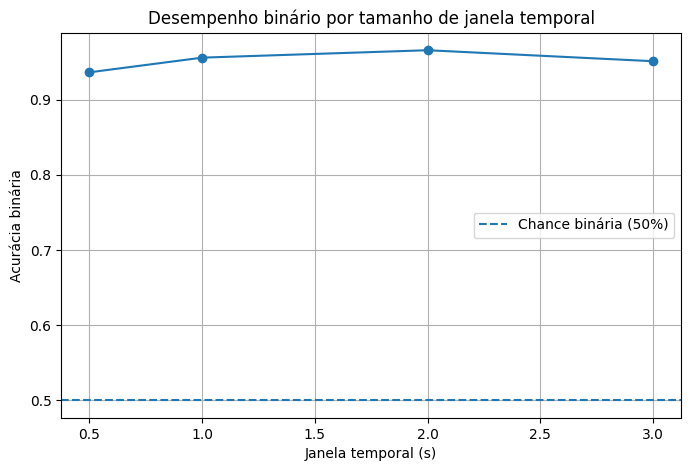

Melhor janela binária por acurácia: 2.0 s
Acurácia binária: 0.965731707317073
Resumo das janelas binárias:
Janela 0.50s | Trials totais antes do filtro binário: 600 | Acurácia binária: 93.63%
Janela 1.00s | Trials totais antes do filtro binário: 600 | Acurácia binária: 95.59%
Janela 2.00s | Trials totais antes do filtro binário: 600 | Acurácia binária: 96.57%
Janela 3.00s | Trials totais antes do filtro binário: 600 | Acurácia binária: 95.11%


In [65]:
janelas_bin = [r['janela_s'] for r in resultados_janelas_binario]
accuracies_bin = [r['accuracy'] for r in resultados_janelas_binario]

melhor_idx_bin = int(np.argmax(accuracies_bin))
melhor_janela_bin = janelas_bin[melhor_idx_bin]
melhor_acc_bin = accuracies_bin[melhor_idx_bin]

plt.figure(figsize=(8, 5))
plt.plot(janelas_bin, accuracies_bin, marker='o')
plt.axhline(0.50, linestyle='--', label='Chance binária (50%)')
plt.xlabel('Janela temporal (s)')
plt.ylabel('Acurácia binária')
plt.title('Desempenho binário por tamanho de janela temporal')
plt.grid(True)
plt.legend()
plt.show()

print("Melhor janela binária por acurácia:", melhor_janela_bin, "s")
print("Acurácia binária:", melhor_acc_bin)

print("Resumo das janelas binárias:")
for r in resultados_janelas_binario:
    print(f"Janela {r['janela_s']:.2f}s | Trials totais antes do filtro binário: {r['n_trials']} | Acurácia binária: {r['accuracy']*100:.2f}%")


## 26.5 - Interpretação da janela adaptativa binária para aplicação assistiva

A formulação binária é a mais próxima de uma aplicação assistiva real, como um sistema que pausa um vídeo quando a atenção do usuário se desloca para fora da região-alvo.

Em uma implementação online, o pipeline conceitual seria:

1. adquirir EEG continuamente;
2. manter um buffer com as amostras recentes;
3. aplicar o mesmo filtro na banda alfa;
4. recortar uma janela temporal com o tamanho escolhido experimentalmente;
5. extrair padrões espaciais via CSP;
6. classificar o estado com SVM;
7. pausar o vídeo se o modelo indicar desvio de atenção por janelas consecutivas.

Assim, a análise adaptativa das janelas não é apenas um teste de desempenho: ela representa uma simulação offline do compromisso entre acurácia e latência que existiria em uma BCI assistiva em tempo real.


# 27 - Interpretação para Tecnologia Assistiva

A análise de janelas temporais permite simular uma restrição importante de uma BCI online: o sistema precisa decidir rapidamente se a atenção do usuário permaneceu na região-alvo ou se foi desviada.

Em uma aplicação assistiva, como um vídeo que pausa quando a atenção se desloca, a lógica seria:

1. adquirir EEG continuamente;
2. manter um buffer das amostras recentes;
3. aplicar filtro na banda alfa;
4. extrair características espaciais via CSP;
5. classificar a direção estimada da atenção;
6. pausar o vídeo se a direção estimada permanecer fora da região-alvo por múltiplas janelas consecutivas.

Assim, a janela adaptativa representa a contribuição própria do grupo, pois avalia o compromisso entre **latência** e **acurácia** para aproximar o pipeline offline de uma aplicação BCI assistiva.